In [80]:
print("Hello from AI Cup")

Hello from AI Cup


In [81]:
!echo hello

hello


In [82]:
import numpy as np
import pandas as pd
from shapely import wkb
import lightgbm as lgb

In [83]:
# import skyfield

# Let's load the data

In [84]:
import pandas as pd

train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")

train_df = train_df.set_index("track_id")
test_df = test_df.set_index("track_id")

train_df

,timestamp_start_radar_utc,timestamp_end_radar_utc,trajectory,trajectory_time,radar_bird_size,airspeed,min_z,max_z,observation_id,primary_observation_id,observer_position,observer_comment,n_birds_observed,bird_group,bird_species
track_id,,,,,,,,,,,,,,,
2537685,2023-09-05 08:59:18,2023-09-05 09:00:52,01020000E0E61000005200000026EE676787321B403B57...,"[0.0, 1.01982, 2.03911, 3.05854, 4.07798, 5.09...",Small bird,16.30710,50.019,151.222,2214,2214,01010000A0E6100000509297E6A2381B407E2E588CE4BA...,NaN,1,Waders,Dunlin
2538937,2023-09-05 09:00:31,2023-09-05 09:02:25,01020000E0E6100000670000000364E067F9351B4030B8...,"[0.0, 1.01519, 2.02996, 4.06014, 5.07671, 7.10...",Small bird,10.78880,0.800,62.424,2215,2215,01010000A0E610000026926751A6301B40D0083ACC62BA...,NaN,1,Gulls,Black-headed Gull
2539560,2023-09-05 09:01:13,2023-09-05 09:03:36,01020000E0E61000007D00000040B7E1C160401B4045EC...,"[0.0, 2.02202, 3.03262, 4.04231, 5.05144, 6.06...",Small bird,11.58620,-1.683,29.396,2216,2216,01010000A0E6100000123E455C15391B40F5A1FA8181BA...,NaN,1,Gulls,European Herring Gull
2541207,2023-09-05 09:06:17,2023-09-05 09:06:49,01020000E0E61000001D000000E051BEFB3E371B40A070...,"[0.0, 1.01909, 2.03129, 3.05113, 5.08457, 6.10...",Small bird,15.01480,-1.847,32.206,2219,2217,01010000A0E61000009EBDB7BDBE391B401C435163D4BA...,NaN,15,Songbirds,Barn Swallow
2541221,2023-09-05 09:06:20,2023-09-05 09:06:51,01020000E0E61000001E000000F49EF3E880371B4050DF...,"[0.0, 1.01682, 3.04788, 4.06614, 5.08373, 6.10...",Small bird,13.79160,2.913,32.478,2218,2217,01010000A0E6100000AF871A62FD3A1B40C2000A91D5BA...,NaN,15,Songbirds,Barn Swallow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582320338,2024-04-30 11:02:40,2024-04-30 11:03:50,01020000E0E61000003D00000000EE68D25C311B40C708...,"[0.0, 0.999011, 1.99955, 2.99724, 5.99992, 8.0...",Large bird,8.93002,-2.122,16.816,1849,1849,01010000A0E610000001288BC3F3311B40B511B82036BA...,NaN,1,Clutter,Clutter
582320867,2024-04-30 11:03:53,2024-04-30 11:04:55,01020000E0E61000002E0000001658F8E1BD2A1B4065E4...,"[0.0, 0.99897, 1.99778, 2.9967, 6.99004, 8.988...",Small bird,15.23130,-0.913,28.773,1851,1851,01010000A0E61000001EDB9C0B292C1B40CE85C177ADB9...,NaN,1,Gulls,Black-headed Gull
582320884,2024-04-30 11:04:04,2024-04-30 11:04:57,01020000E0E61000003400000089E6C78068311B4002BE...,"[0.0, 0.999006, 2.00149, 3.00305, 4.00421, 5.0...",Medium bird,17.97540,5.377,23.922,1852,1852,01010000A0E6100000849077D0C9351B40C67555F3B8BA...,NaN,1,Gulls,Lesser Black-backed Gull


# Let's explore the data

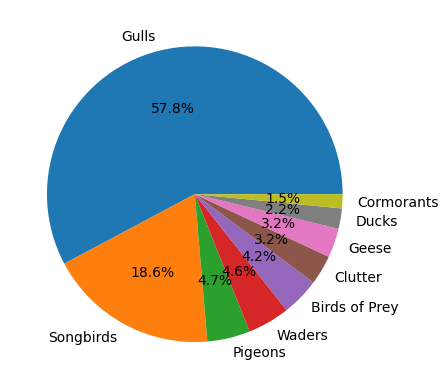

In [85]:
import matplotlib.pyplot as plt

train_df['bird_group'].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

In [86]:
from shapely import wkb

wkb_hex = train_df['trajectory'].iloc[0]
 
geom = wkb.loads(bytes.fromhex(wkb_hex))
coords = list(geom.coords)

coords

[(6.79934465, 53.45849494, 51.576, -32.3),
 (6.79955911, 53.45855682, 50.019, -31.9),
 (6.79974432, 53.45860298, 51.826, -26.3),
 (6.79993511, 53.45864817, 52.74, -26.0),
 (6.80013858, 53.4586728, 54.564, -37.8),
 (6.80036251, 53.45868946, 56.161, -37.3),
 (6.80053995, 53.45862705, 56.994, -36.5),
 (6.80055064, 53.45845121, 59.155, -38.0),
 (6.80074574, 53.45840345, 60.002, -39.7),
 (6.80097011, 53.45840502, 61.596, -36.7),
 (6.80117407, 53.45842036, 64.169, -35.2),
 (6.80136176, 53.45848945, 66.491, -22.1),
 (6.80153182, 53.45861544, 67.774, -33.0),
 (6.8016236, 53.45871828, 69.03, -24.6),
 (6.80174753, 53.45880143, 69.754, -25.2),
 (6.80191692, 53.45887956, 71.851, -29.8),
 (6.80210679, 53.4589564, 73.965, -29.1),
 (6.80228943, 53.45904181, 76.079, -25.5),
 (6.80243277, 53.45907539, 77.44, -36.7),
 (6.80263052, 53.45912817, 78.844, -35.3),
 (6.80283209, 53.45918778, 81.472, -29.2),
 (6.80325836, 53.45923708, 84.451, -27.9),
 (6.80358669, 53.45927139, 86.093, -37.9),
 (6.80383824, 53.

In [87]:
def parse_trajectory(hex_str):
    """Decode EWKB hex string into a list of (lon, lat, alt, rcs) tuples."""
    if not isinstance(hex_str, str) or len(hex_str) == 0:
        return []
    try:
        # Load hex string (support both WKB and EWKB)
        geom = wkb.loads(bytes.fromhex(hex_str) if not hex_str.startswith('\x01') else hex_str, hex=True)
        if geom.geom_type == 'LineString':
            return list(geom.coords)
        elif geom.geom_type == 'Point':
            return [geom.coords[0]]
        elif geom.geom_type in ('MultiPoint', 'GeometryCollection'):
            return [g.coords[0] for g in geom.geoms]
    except Exception:
        pass
    return []

def trajectory_features(row):
    """Extract numerous spatial and numeric features from a trajectory."""
    coords = parse_trajectory(row['trajectory'])
    n = len(coords)
    if n == 0:
        return pd.Series({})

    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    alts = [c[2] for c in coords] if len(coords[0]) > 2 else [np.nan]*n
    rcs  = [c[3] for c in coords] if len(coords[0]) > 3 else [np.nan]*n

    # Convert lat/lon distance to approx meters
    dx = np.diff(lons) * 71000   
    dy = np.diff(lats) * 111000  
    step_dist = np.sqrt(dx**2 + dy**2)
    total_dist = step_dist.sum() if len(step_dist) > 0 else 0.0

    # Tortuosity (turning behavior)
    bearings = np.arctan2(dy, dx)
    bearing_changes = np.abs(np.diff(bearings)) if len(bearings) > 1 else np.array([0.0])
    bearing_changes = np.minimum(bearing_changes, 2*np.pi - bearing_changes) 

    return pd.Series({
        'n_points'           : n,
        'total_dist_m'       : total_dist,
        'mean_step_m'        : step_dist.mean() if len(step_dist) > 0 else 0.0,
        'std_step_m'         : step_dist.std()  if len(step_dist) > 0 else 0.0,
        'lon_range'          : max(lons) - min(lons),
        'lat_range'          : max(lats) - min(lats),
        'alt_mean'           : np.nanmean(alts),
        'alt_std'            : np.nanstd(alts),
        'rcs_mean'           : np.nanmean(rcs),
        'rcs_std'            : np.nanstd(rcs),
        'rcs_min'            : np.nanmin(rcs),
        'rcs_max'            : np.nanmax(rcs),
        'tortuosity'         : bearing_changes.mean() if len(bearing_changes) > 0 else 0.0,
        'tortuosity_max'     : bearing_changes.max() if len(bearing_changes) > 0 else 0.0,
    })

In [88]:
def split_xyzm(wkb_hex):
    geom = wkb.loads(bytes.fromhex(wkb_hex))
    coords = list(geom.coords)

    xs, ys, zs, RCSs = zip(*coords)

    return pd.Series({
        "x": xs,
        "y":ys,
        "z":zs,
        "RCS":RCSs
    })





# extra_train_cols = train_df['trajectory'].apply(split_xyzm)
# extra_test_cols = test_df['trajectory'].apply(split_xyzm)

# train_df = train_df.join(extra_train_cols)

# test_df = test_df.join(extra_test_cols)

# train_df['mean_RCS'] = train_df['RCS'].apply(np.mean)
# test_df['mean_RCS'] = test_df['RCS'].apply(np.mean)

test_df

,timestamp_start_radar_utc,timestamp_end_radar_utc,trajectory,trajectory_time,radar_bird_size,airspeed,min_z,max_z
track_id,,,,,,,,
6868504,2023-09-12 07:32:03,2023-09-12 07:32:15,01020000E0E61000000C0000001CE392FCEB391B404F2D...,"[0.0, 1.01691, 2.0349, 3.04959, 4.06951, 5.089...",Flock,21.1292,42.711,49.101
6868536,2023-09-12 07:32:03,2023-09-12 07:32:19,01020000E0E61000000F0000002D667C46BF391B409163...,"[0.0, 1.02105, 2.0403, 3.06218, 4.08264, 5.106...",Flock,24.9480,39.892,45.495
6868565,2023-09-12 07:32:03,2023-09-12 07:32:23,01020000E0E61000001400000019543CAA71391B409B92...,"[0.0, 1.02037, 2.04036, 3.0603, 4.0825, 5.1028...",Large bird,18.5307,42.994,50.100
6868861,2023-09-12 07:32:03,2023-09-12 07:33:06,01020000E0E610000039000000E1600C388D391B40B1E7...,"[0.0, 1.01986, 3.0611, 4.08251, 5.10223, 7.147...",Large bird,17.7535,43.493,56.919
6869275,2023-09-12 07:32:04,2023-09-12 07:34:00,01020000E0E61000006C0000000FC61DA99D391B40B9ED...,"[0.0, 2.04045, 3.0644, 4.08169, 5.10318, 6.124...",Flock,18.0350,38.364,68.100
...,...,...,...,...,...,...,...,...
589734589,2024-05-10 10:05:30,2024-05-10 10:05:51,01020000E0E610000013000000B497A75237381B4043E9...,"[0.0, 1.99119, 2.98708, 3.98369, 5.97631, 6.97...",Small bird,12.9431,96.301,110.376
589734601,2024-05-10 10:05:10,2024-05-10 10:05:52,01020000E0E61000002400000024E5F6E4C4371B406A10...,"[0.0, 0.994542, 1.98745, 2.98034, 5.95933, 6.9...",Medium bird,14.9002,69.182,117.652
589735157,2024-05-10 10:04:53,2024-05-10 10:06:26,01020000E0E61000005300000020C18523E5321B407697...,"[0.0, 2.00354, 3.00567, 4.00863, 5.01071, 8.01...",Small bird,15.2171,8.736,60.906


In [89]:
for df in [train_df, test_df]:
    # Parse UTC timestamps
    df['ts_start'] = pd.to_datetime(df['timestamp_start_radar_utc'], utc=True)
    df['ts_end']   = pd.to_datetime(df['timestamp_end_radar_utc'],   utc=True)
    df['duration_s'] = (df['ts_end'] - df['ts_start']).dt.total_seconds()
    
    # Extract time-of-day / seasonality features
    df['hour']       = df['ts_start'].dt.hour
    df['month']      = df['ts_start'].dt.month
    df['is_daytime'] = ((df['hour'] >= 6) & (df['hour'] <= 20)).astype(int)
    
    # Derived features calculation
    df['alt_range']      = df['max_z'] - df['min_z']
    df['airspeed_per_m'] = df['airspeed'] / (df['max_z'] + 1)
    
print("Applying advanced trajectory features for train_df (this may take a minute) ...")
extra_train_cols = train_df.apply(trajectory_features, axis=1)
train_df = train_df.join(extra_train_cols)

print("Applying advanced trajectory features for test_df...")
extra_test_cols = test_df.apply(trajectory_features, axis=1)
test_df = test_df.join(extra_test_cols)

Applying advanced trajectory features for train_df (this may take a minute) ...
Applying advanced trajectory features for test_df...


In [90]:
# import seaborn as sns

# num_cols_to_plot = ['airspeed', 'max_z', 'mean_RCS']

# for feat in num_cols_to_plot:
#     plt.figure(figsize=(12,6))
#     sns.boxplot(data=train_df, x='bird_group', y=feat, palette='viridis', hue='bird_group')
#     plt.title(f"{feat} per bird_group")
#     plt.xticks(rotation=45)
#     plt.show()
#     plt.close()

# Prepare features


In [91]:
#model input X
#model targets y

# features = ['airspeed', 'min_z', 'max_z', 'mean_RCS', 'radar_bird_size']

# X = train_df[features]
# X_test = test_df[features]

features = [
    'airspeed', 'min_z', 'max_z', 'duration_s', 'radar_bird_size',
    'hour', 'month', 'is_daytime', 'alt_range', 'airspeed_per_m',
    'n_points', 'total_dist_m', 'mean_step_m', 'std_step_m',
    'lon_range', 'lat_range', 'alt_mean', 'alt_std',
    'rcs_mean', 'rcs_std', 'rcs_min', 'rcs_max', 'tortuosity', 'tortuosity_max'
]

X = train_df[features]
X_test = test_df[features]

y = train_df['bird_group']

X

print(X_test)

           airspeed   min_z    max_z  duration_s radar_bird_size  hour  month  \
track_id                                                                        
6868504     21.1292  42.711   49.101        12.0           Flock     7      9   
6868536     24.9480  39.892   45.495        16.0           Flock     7      9   
6868565     18.5307  42.994   50.100        20.0      Large bird     7      9   
6868861     17.7535  43.493   56.919        63.0      Large bird     7      9   
6869275     18.0350  38.364   68.100       116.0           Flock     7      9   
...             ...     ...      ...         ...             ...   ...    ...   
589734589   12.9431  96.301  110.376        21.0      Small bird    10      5   
589734601   14.9002  69.182  117.652        42.0     Medium bird    10      5   
589735157   15.2171   8.736   60.906        93.0      Small bird    10      5   
589735318   13.1801   8.565   65.829       104.0      Small bird    10      5   
589735967   13.3897  47.974 

In [92]:
y

track_id
2537685             Waders
2538937              Gulls
2539560              Gulls
2541207          Songbirds
2541221          Songbirds
                 ...      
582320338          Clutter
582320867            Gulls
582320884            Gulls
582321034    Birds of Prey
582322274            Gulls
Name: bird_group, Length: 2601, dtype: str

# Setup the pipeline


In [93]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

In [94]:
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer  
from imblearn.pipeline import Pipeline as ImbPipeline  
from imblearn.over_sampling import SMOTE
from sklearn.compose import make_column_selector
# numeric_transformer = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler())
# ])


# preprocessor = ColumnTransformer(
#     [('cat', OneHotEncoder(), ['radar_bird_size'])],
#     remainder='passthrough'
# )

# pipeline = Pipeline([
#     ('preprocess', preprocessor),
#     ('model', HistGradientBoostingClassifier(random_state=42))
# ])

# Preprocessing for numeric columns: impute median then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical columns: impute most frequent then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include='number')),
        ('cat', categorical_transformer, make_column_selector(dtype_include='object'))
    ])

# Final pipeline: preprocessing -> SMOTE -> ensemble classifier
# pipeline = ImbPipeline([
#     ('preprocess', preprocessor),
#     ('smote', SMOTE(random_state=42)),                     # generates synthetic samples for minority class
#     ('model', HistGradientBoostingClassifier(random_state=42))
# ])
pipeline = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', lgb_model)
])


# Cross validation

In [95]:
from sklearn.model_selection import StratifiedKFold

n_splits = 5

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

split = list(cv.split(X, y))

for i, (train_idx, val_idx) in enumerate(split):
    print(f"fold {i+1} train: {len(train_idx)}, val:  {len(val_idx)}" )

fold 1 train: 2080, val:  521
fold 2 train: 2081, val:  520
fold 3 train: 2081, val:  520
fold 4 train: 2081, val:  520
fold 5 train: 2081, val:  520


# Training the model


In [96]:
from sklearn.base import clone

classes = np.unique(y)

oof_preds = pd.DataFrame(0.0, index=X.index, columns=classes)

test_preds = np.zeros((len(X_test), len(classes)))

for i, (train_idx, val_idx) in enumerate(split):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_val = X.iloc[val_idx]
    y_val = y.iloc[val_idx]

    pipeline_fold = clone(pipeline)

    pipeline_fold.fit(X_train, y_train)

    val_preds = pipeline_fold.predict_proba(X_val)
    oof_preds.iloc[val_idx] = val_preds

    test_preds_fold = pipeline_fold.predict_proba(X_test)

    test_preds += test_preds_fold

    print(f"Trained fold{i+1}/{n_splits}!")
    

/home/lucypher/Desktop/aicup/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/lucypher/Desktop/aicup/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Trained fold1/5!


/home/lucypher/Desktop/aicup/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/lucypher/Desktop/aicup/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Trained fold2/5!


/home/lucypher/Desktop/aicup/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/lucypher/Desktop/aicup/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Trained fold3/5!


/home/lucypher/Desktop/aicup/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/lucypher/Desktop/aicup/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Trained fold4/5!
Trained fold5/5!


/home/lucypher/Desktop/aicup/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/lucypher/Desktop/aicup/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [97]:
oof_preds

,Birds of Prey,Clutter,Cormorants,Ducks,Geese,Gulls,Pigeons,Songbirds,Waders
track_id,,,,,,,,,
2537685,0.021387,6.176393e-05,5.414544e-04,9.987406e-05,3.250855e-04,0.739633,7.780705e-04,2.228497e-02,2.148887e-01
2538937,0.000026,9.792431e-09,1.753074e-08,1.225597e-08,2.407663e-08,0.999973,4.519086e-08,5.409931e-08,2.090659e-07
2539560,0.000044,1.505856e-07,1.052156e-05,4.403829e-07,2.753761e-06,0.999939,4.817915e-07,1.431135e-06,3.883019e-07
2541207,0.000755,5.230597e-06,6.892557e-07,3.429862e-06,3.685108e-07,0.060030,2.784143e-06,9.391957e-01,7.009971e-06
2541221,0.000494,4.138977e-07,5.518306e-07,3.801076e-07,2.657794e-07,0.076497,3.048238e-06,9.230020e-01,2.170540e-06
...,...,...,...,...,...,...,...,...,...
582320338,0.000001,9.999432e-01,3.337187e-08,1.242066e-07,1.425352e-07,0.000053,1.142452e-08,1.337993e-06,3.871088e-07
582320867,0.000013,7.281771e-08,7.090250e-07,1.250253e-07,4.265549e-08,0.999967,8.620363e-08,1.793245e-05,7.317114e-07
582320884,0.001780,2.383998e-05,4.086051e-03,1.246666e-04,3.144040e-04,0.990907,6.545059e-05,9.044324e-05,2.607735e-03


In [98]:
import pandas as pd
import sklearn.metrics

def score(
    solution: pd.DataFrame, 
    submission: pd.DataFrame, 
) -> float:
    #Takes in two pandas dataframe and computes the Macro-averaged Average Precision Score
   
    # Ensure all required columns are present
    needed_columns = [
        "Clutter", 
        "Cormorants", 
        "Pigeons", 
        "Ducks", 
        "Geese", 
        "Gulls", 
        "Birds of Prey", 
        "Waders", 
        "Songbirds",
    ]
    
    # Reorder solution and submission columns/rows to match exactly
    solution = solution.loc[solution.index, needed_columns]
    submission = submission.loc[solution.index, needed_columns]

    
    # Compute the Average Precision score for all required columns
    bird_score = sklearn.metrics.average_precision_score(
        solution[needed_columns],
        submission[needed_columns],
        average='macro'
    )

    return bird_score

In [99]:
# Get local OOF CV score
solution_df = (
    train_df
    .groupby(["track_id", "bird_group"])
    .size()
    .unstack(fill_value=0)
)

oof_score = score(solution_df, oof_preds)

print(f"OOF score: {oof_score}")

OOF score: 0.6387187425028186


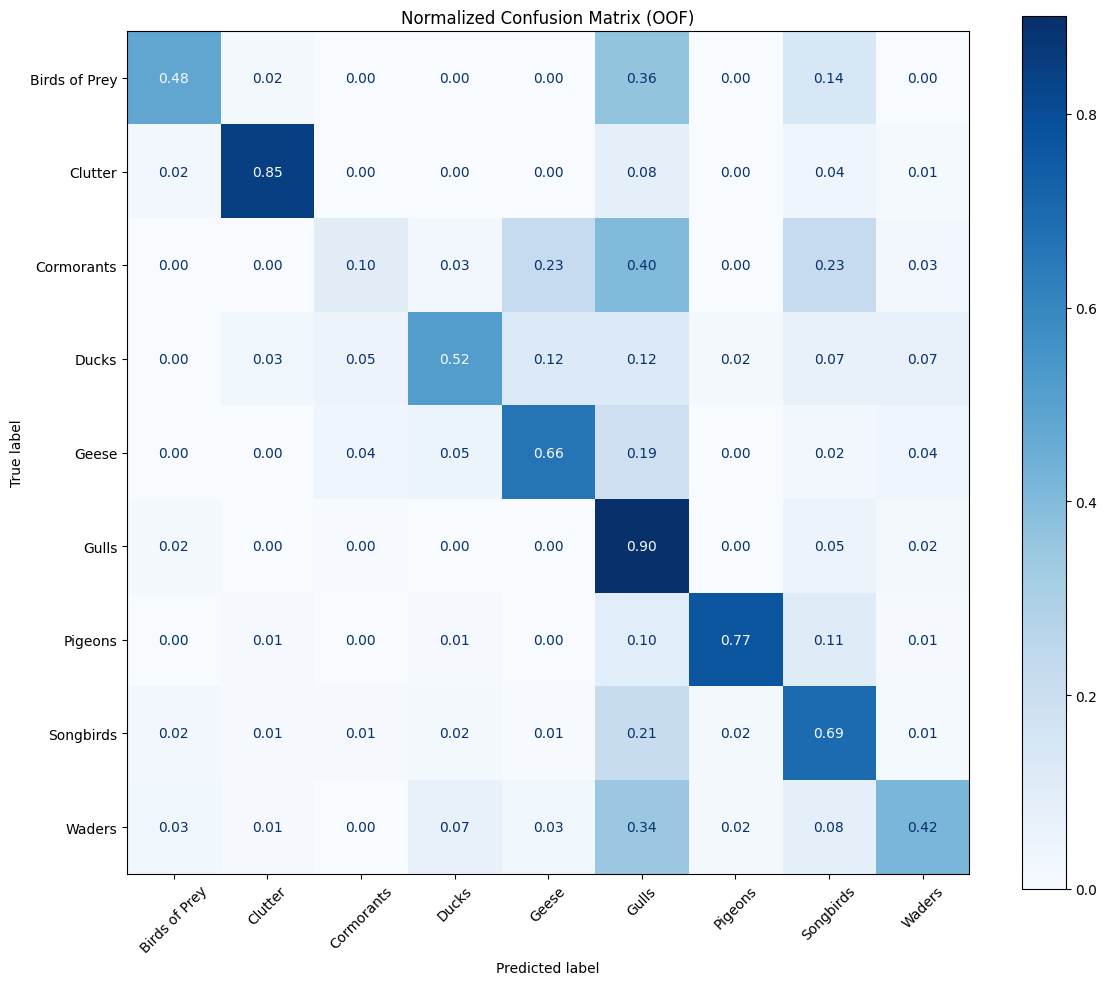

In [100]:
from sklearn.metrics import ConfusionMatrixDisplay

# Convert OOF probabilities to hard class labels
y_pred_oof = classes[np.argmax(oof_preds, axis=1)]

# Plot Normalized Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y, 
    y_pred_oof, 
    display_labels=classes,
    cmap="Blues",
    normalize='true',
    values_format=".2f",
    xticks_rotation=45,
    ax=ax
)

plt.title("Normalized Confusion Matrix (OOF)")
plt.tight_layout()
plt.show()
plt.close()


In [101]:
submission_df = pd.DataFrame(
    test_preds / n_splits,
    index=X_test.index,
    columns=classes
)

submission_df.to_csv('submission.csv')

print("Saved to submission.csv")

submission_df.head()

Saved to submission.csv


,Birds of Prey,Clutter,Cormorants,Ducks,Geese,Gulls,Pigeons,Songbirds,Waders
track_id,,,,,,,,,
6868504,4.735658e-06,5.893044e-05,0.000146,0.004455,0.982346,0.012598,1.718731e-04,0.000173,0.000046
6868536,7.224549e-06,1.188724e-03,0.000439,0.001085,0.885829,0.109849,2.236870e-04,0.000879,0.000500
6868565,1.058563e-05,1.158170e-04,0.093247,0.008817,0.879305,0.016028,1.365744e-03,0.000194,0.000917
6868861,6.975513e-08,3.234071e-07,0.137346,0.000025,0.862542,0.000052,1.591978e-05,0.000002,0.000016
6869275,7.757058e-08,2.547529e-07,0.000532,0.000003,0.999354,0.000080,8.799254e-07,0.000004,0.000026
